# X-ray spectra by epoch, with absorbed apec fit

Same 3-panel layout as `xray_spectra_by_epoch.ipynb` (data points, `group_counts(15)`,
background-subtracted, 0.3-8 keV, chronological left to right), with the best-fit
`tbabs*apec` (absorbed single-temperature thermal plasma) model curve overlaid. Each
panel has a data-model residuals sub-panel directly below it (added 2026-09-02, per
advisor guidance).

Fit details (`data/Chandra/spectral_fitting/fit_models.py`, run under `ciao-4.17` for
Sherpa): N_H frozen at the Galactic value toward SN 2018ivc (2.6e20 cm^-2, from
HEASoft's `nh` tool / HI4PI survey), apec abundance frozen at solar, redshift frozen
at 0.003793. kT and norm free. Fit statistic: **wstat** (not cstat — cstat cannot be
used with background-subtracted data; wstat is the Poisson-source/Poisson-background
analog that doesn't require subtracting, appropriate here since the source is fit
without `subtract()`). Uncertainties are 1-sigma `conf()` intervals where Sherpa's
default fit-quality guard allowed them to be computed.

**Color: each epoch's data points use its position in the single project-wide
viridis epoch list in `CLAUDE_plotting.md`** (shared with the radio SEDs, updated
2026-09-01 to interleave these 3 X-ray epochs into that list). The best-fit model
curve uses a darkened version of the same epoch color (`darken_color`, per
`CLAUDE_plotting.md`'s model/fit-curve convention), rather than an unrelated fixed
color, so data and fit stay visibly linked per epoch while still being
distinguishable from each other. The residual sub-panels reuse the same per-epoch
data color.

Model curves and fit results come from `data/Chandra/spectral_fitting/fits/apec/`
and `fit_summary.csv`. Residuals (data-model, `energy_kev`/`energy_err_kev`/`resid`/
`resid_err`) come from `fits/apec/<epoch>_resid.csv`, computed via Sherpa's
`get_resid_plot` at the same `group_counts(15)` bin resolution as the data — not by
naively interpolating the fine-grained `_model.csv` curve, which is evaluated at much
finer resolution than the actual fit bins. This notebook only plots, under the
standard `18ivc_clean` kernel — see `CLAUDE_xray_SOP.md` Step 4 for the full
fit-result summary and caveats.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from astropy.io import fits
from astropy.time import Time
import functions

functions.set_plot_style()

MODEL_NAME = "apec"
PRIMARY_PARAM = "apec1.kT"
PARAM_LABEL = "kT"
PARAM_UNIT = "keV"

GROUPING_QA_DIR = "../data/Chandra/spectral_fitting/grouping_qa"
FITS_DIR = f"../data/Chandra/spectral_fitting/fits/{MODEL_NAME}"
SUMMARY_CSV = "../data/Chandra/spectral_fitting/fits/fit_summary.csv"
T_EXPLOSION_MJD = 58445.0  # Maeda et al. 2023a

EPOCH_FILES = [
    ("20306", "20306", "../data/Chandra/20306/repro/SN2018ivc_specextract.pi"),
    ("29071_29072", "29071+29072", "../data/Chandra/29071_29072_merged/SN2018ivc_merged_src.pi"),
    ("31211_31996", "31211+31996", "../data/Chandra/31211_31996_merged/SN2018ivc_merged_src.pi"),
]

# Position of each X-ray epoch in the single project-wide viridis epoch list
# (CLAUDE_plotting.md "Epoch -> viridis color (SEDs)", x = linspace(1,0,11)).
EPOCH_VIRIDIS_X = {
    "20306": 0.900,        # 12.7 d
    "29071_29072": 0.400,  # 1868.7 d
    "31211_31996": 0.100,  # 2550.3 d
}

def darken_color(color, factor=0.6):
    rgb = mcolors.to_rgb(color)
    return tuple(factor * c for c in rgb)

def epoch_title(display_label, path):
    h = fits.open(path)[1].header
    date_obs = h["DATE-OBS"][:10]
    mjd = Time(h["DATE-OBS"], format="isot", scale="utc").mjd
    phase_days = mjd - T_EXPLOSION_MJD
    return f"{display_label} ({date_obs}, ~{phase_days:.0f} days post-explosion)", phase_days

panels = []
for epoch_key, display_label, path in EPOCH_FILES:
    title, phase_days = epoch_title(display_label, path)
    panels.append((phase_days, epoch_key, title))
panels.sort(key=lambda p: p[0])

cmap = mpl.colormaps["viridis"]
epoch_colors = {k: cmap(x) for k, x in EPOCH_VIRIDIS_X.items()}
model_colors = {k: darken_color(c) for k, c in epoch_colors.items()}

summary = pd.read_csv(SUMMARY_CSV)
summary = summary[summary["model"] == MODEL_NAME].set_index("epoch")

def fit_label(epoch_key):
    row = summary.loc[epoch_key]
    val = row[f"{PRIMARY_PARAM}_val"]
    pegged = row.get(f"{PRIMARY_PARAM}_pegged", False)
    if pegged:
        return f"{PARAM_LABEL} = {val:.1f} {PARAM_UNIT} (pegged at bound)\n$W$/dof = {row['statval']:.1f}/{row['dof']:.0f}"
    lo, hi = row.get(f"{PRIMARY_PARAM}_errlo"), row.get(f"{PRIMARY_PARAM}_errhi")
    if pd.notna(lo) and pd.notna(hi):
        return f"{PARAM_LABEL} = {val:.2f}$^{{+{hi:.2f}}}_{{{lo:.2f}}}$ {PARAM_UNIT}\n$W$/dof = {row['statval']:.1f}/{row['dof']:.0f}"
    return f"{PARAM_LABEL} = {val:.2f} {PARAM_UNIT} (err. unconstrained)\n$W$/dof = {row['statval']:.1f}/{row['dof']:.0f}"

/opt/anaconda3/envs/18ivc_clean/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


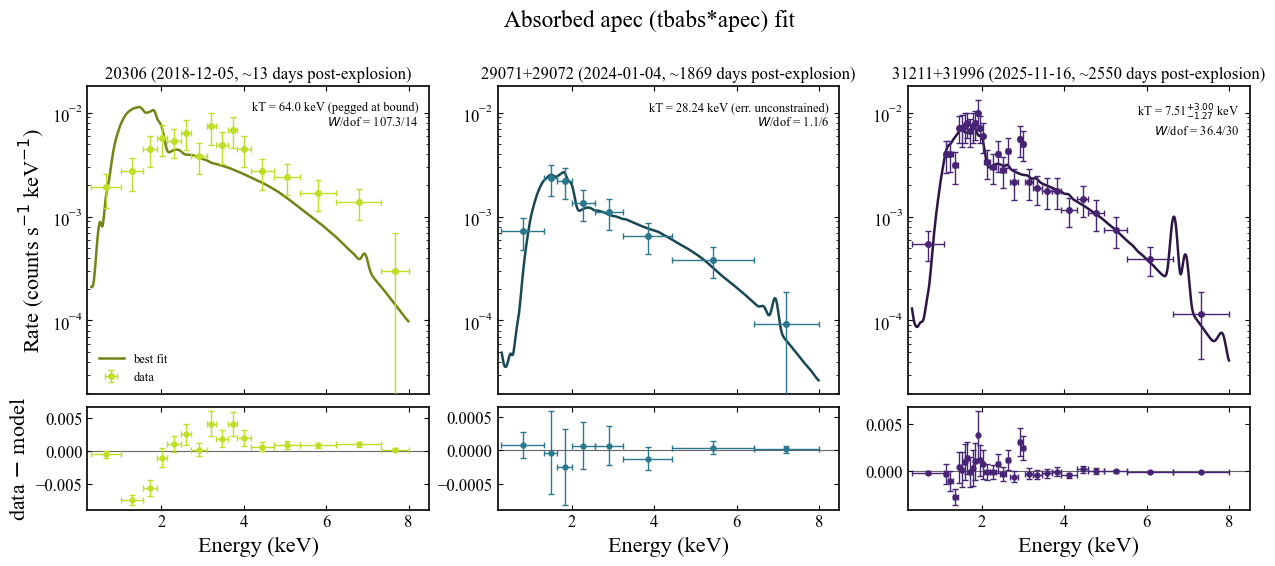

In [2]:
RESID_DIR = f"../data/Chandra/spectral_fitting/fits/{MODEL_NAME}"

fig = plt.figure(figsize=(15, 5.5))
gs = fig.add_gridspec(2, 3, height_ratios=[3, 1], hspace=0.06)

spec_axes = [fig.add_subplot(gs[0, 0])]
spec_axes += [fig.add_subplot(gs[0, i], sharex=spec_axes[0], sharey=spec_axes[0]) for i in (1, 2)]
resid_axes = [fig.add_subplot(gs[1, i], sharex=spec_axes[i]) for i in range(3)]

for ax, rax, (phase_days, epoch_key, title) in zip(spec_axes, resid_axes, panels):
    df = pd.read_csv(f"{GROUPING_QA_DIR}/{epoch_key}_group15.csv")
    ax.errorbar(
        df["energy_kev"], df["rate"],
        xerr=df["energy_err_kev"], yerr=df["rate_err"],
        fmt="o", ms=4, capsize=2, lw=1.2, elinewidth=1,
        color=epoch_colors[epoch_key], zorder=3, label="data",
    )

    mdf = pd.read_csv(f"{FITS_DIR}/{epoch_key}_model.csv")
    ax.plot(mdf["energy_kev"], mdf["rate"], "-", color=model_colors[epoch_key], lw=1.8, zorder=2, label="best fit")

    ax.set_title(title, fontsize=12)
    ax.set_yscale("log")
    ax.set_xlim(0.2, 8.5)
    ax.text(
        0.97, 0.95, fit_label(epoch_key), transform=ax.transAxes,
        ha="right", va="top", fontsize=9,
    )
    plt.setp(ax.get_xticklabels(), visible=False)

    rdf = pd.read_csv(f"{RESID_DIR}/{epoch_key}_resid.csv")
    rax.axhline(0, color="0.4", lw=0.8, zorder=1)
    rax.errorbar(
        rdf["energy_kev"], rdf["resid"],
        xerr=rdf["energy_err_kev"], yerr=rdf["resid_err"],
        fmt="o", ms=3.5, capsize=2, lw=1.0, elinewidth=1,
        color=epoch_colors[epoch_key], zorder=3,
    )
    rax.set_xlim(0.2, 8.5)
    rax.set_xlabel("Energy (keV)")

spec_axes[0].set_ylabel(r"Rate (counts s$^{-1}$ keV$^{-1}$)")
spec_axes[0].legend(fontsize=9, frameon=False, loc="lower left")
resid_axes[0].set_ylabel("data $-$ model")

fig.suptitle("Absorbed apec (tbabs*apec) fit", y=1.02)
fig.savefig(f"../figures/xray_spectra_{MODEL_NAME}_fit.png", dpi=200, bbox_inches="tight")
fig.savefig(f"../figures/xray_spectra_{MODEL_NAME}_fit.pdf", bbox_inches="tight")
plt.show()